# Data deleted Models

## 1. Loading the data

In [37]:
import pandas as pd

data_deleted = pd.read_parquet("data_processed/data_deleted.parquet")

print(len(data_deleted))
print(data_deleted.columns.tolist())
print(data_deleted.head(5))

482188
['puuid', 'match_id', 'team', 'role', 'champion', 'traj_len', 'x0', 'y0', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'x22', 'y22', 'x23', 'y23', 'x24', 'y24', 'x25', 'y25', 'x26', 'y26', 'x27', 'y27', 'x28', 'y28', 'x29', 'y29', 'x30', 'y30', 'x31', 'y31', 'x32', 'y32', 'x33', 'y33', 'x34', 'y34', 'x35', 'y35', 'x36', 'y36', 'x37', 'y37', 'x38', 'y38', 'x39', 'y39', 'x40', 'y40', 'x41', 'y41', 'x42', 'y42', 'x43', 'y43', 'x44', 'y44', 'x45', 'y45', 'x46', 'y46', 'x47', 'y47', 'x48', 'y48', 'x49', 'y49', 'x50', 'y50', 'x51', 'y51', 'x52', 'y52', 'x53', 'y53', 'x54', 'y54', 'x55', 'y55', 'x56', 'y56', 'x57', 'y57', 'x58', 'y58', 'x59', 'y59']
                                               puuid         match_id  team  \
0  mCG4W3ohaS1yeYuEIpAiXCgHPyOb_

### 2. Baseline: Champion -> Role

A good idea for the baseline would be a majority vote of roles for every champion.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Mapping
data_baseline = data_deleted[['champion', 'role']]

data_train, data_test = train_test_split(data_baseline, test_size=0.2)

model_map = data_train.groupby('champion')['role'].agg(lambda x: x.mode()[0])
y_pred_map = data_test['champion'].map(model_map)

# Logistic Regression
X = data_deleted[['champion']].copy()
y = data_deleted['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

pipeline = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=100, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Models review
print("="*50)
print("MAPPING BASELINE")
print("="*50)
acc_map = accuracy_score(data_test['role'], y_pred_map)
print(f"Accuracy: {acc_map:.4f}")
print("\nClassification Report:")
print(classification_report(data_test['role'], y_pred_map))

print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)
acc_lr = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n" + "="*50)
print("PODSUMOWANIE")
print("="*50)
print(f"Mapping:     {acc_map:.4f}")
print(f"Logistic R.: {acc_lr:.4f}")
print(f"Difference:     {(acc_lr - acc_map):.4f}")

MAPPING BASELINE
Accuracy: 0.8355

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.91      0.93      0.92     19223
      JUNGLE       0.78      0.84      0.81     19430
      MIDDLE       0.78      0.73      0.75     18979
         TOP       0.79      0.76      0.78     19341
     UTILITY       0.91      0.92      0.91     19465

    accuracy                           0.84     96438
   macro avg       0.83      0.84      0.83     96438
weighted avg       0.83      0.84      0.83     96438


LOGISTIC REGRESSION
Accuracy: 0.8360

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.91      0.93      0.92     19122
      JUNGLE       0.78      0.84      0.81     19388
      MIDDLE       0.77      0.73      0.75     19126
         TOP       0.79      0.76      0.78     19285
     UTILITY       0.92      0.91      0.91     19517

    accuracy                           0.84     96438
   macro av

### 3. Trajectories - Comparing different roles

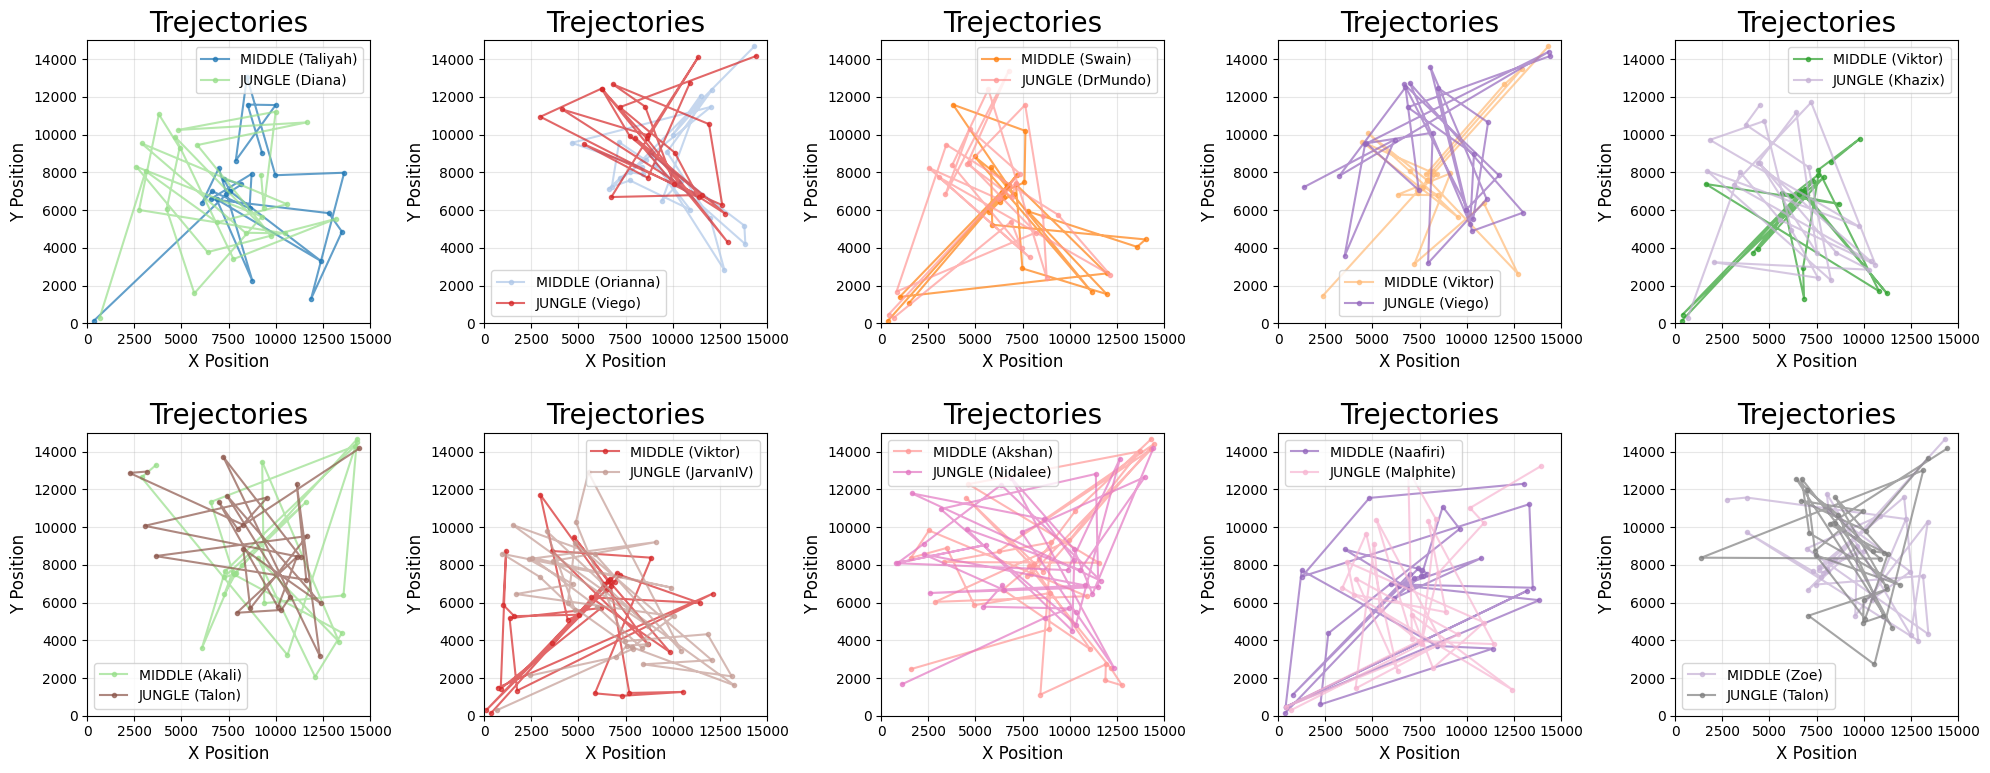

In [39]:
import matplotlib.pyplot as plt

n_samples = 10
roles = ['MIDDLE', 'JUNGLE']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

colors = plt.cm.tab20(range(n_samples+5))

for i in range(len(roles)):
    role = roles[i]
    for idx in range(n_samples):
        ax = axes[idx]
        data_by_role = data_deleted[data_deleted['role'] == role]

        x_positions = [data_by_role.iloc[idx][f'x{i}'] for i in range(40)]
        y_positions = [data_by_role.iloc[idx][f'y{i}'] for i in range(40)]

        champion = data_by_role.iloc[idx]['champion']

        ax.plot(x_positions, y_positions, '-o', color= colors[idx + 5*i], markersize=3, linewidth=1.5, label=f"{role} ({champion})", alpha=0.7)

        ax.set_title(f'Trejectories', fontsize=20)
        ax.set_xlabel('X Position', fontsize=12)
        ax.set_ylabel('Y Position', fontsize=12)
        ax.set_xlim(0, 15000)
        ax.set_ylim(0, 15000)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### 3.1 Random Forest - First Try

In [40]:
from sklearn.ensemble import RandomForestClassifier

position_cols = [col for col in data_deleted.columns if col.startswith(('x', 'y'))]
X = data_deleted[position_cols] 
y = data_deleted['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_rf = RandomForestClassifier(n_estimators=20)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)

RANDOM FOREST
Accuracy: 0.9998

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     19351
      JUNGLE       1.00      1.00      1.00     19307
      MIDDLE       1.00      1.00      1.00     19101
         TOP       1.00      1.00      1.00     19229
     UTILITY       1.00      1.00      1.00     19450

    accuracy                           1.00     96438
   macro avg       1.00      1.00      1.00     96438
weighted avg       1.00      1.00      1.00     96438


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8355
Logistic Regression  0.8360
Random Forest        0.9998


#### Observation 

Having almost 100% accuracy is suspect ඞ.

In [41]:
model_feature_importances = pd.DataFrame({
    'columns': model_rf.feature_names_in_,
    'importances': model_rf.feature_importances_,
    
})
model_feature_importances[model_feature_importances['importances']>0.03]

,columns,importances
0,x0,0.148065
1,y0,0.132973
2,x1,0.043922
3,y1,0.099327
4,x2,0.073636
5,y2,0.087356
7,y3,0.030864
9,y4,0.033598
11,y5,0.034001


No single feature has importance higher than 0.2, as we have 120 features to evaluate for importance. Even so we can notice that there is a rather sharp drop from  x0/y0 to x1/y1.

In [42]:
model_x0 = RandomForestClassifier()
model_x0.fit(X_train[['x0']],y_train)
y_pred_x0 = model_x0.predict(X_test[['x0']])

print("="*50)
print("MODEL WITH X0 AS THE SOLE FEATURE")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_x0)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)


MODEL WITH X0 AS THE SOLE FEATURE
Accuracy: 0.9999

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     19351
      JUNGLE       1.00      1.00      1.00     19307
      MIDDLE       1.00      1.00      1.00     19101
         TOP       1.00      1.00      1.00     19229
     UTILITY       1.00      1.00      1.00     19450

    accuracy                           1.00     96438
   macro avg       1.00      1.00      1.00     96438
weighted avg       1.00      1.00      1.00     96438


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8355
Logistic Regression  0.8360
Random Forest        0.9999


In [43]:
model_x0 = RandomForestClassifier()
model_x0.fit(X_train[['y0']],y_train)
y_pred_x0 = model_x0.predict(X_test[['y0']])

print("="*50)
print("MODEL WITH Y0 AS THE SOLE FEATURE")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_x0)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)

MODEL WITH Y0 AS THE SOLE FEATURE
Accuracy: 0.9999

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     19351
      JUNGLE       1.00      1.00      1.00     19307
      MIDDLE       1.00      1.00      1.00     19101
         TOP       1.00      1.00      1.00     19229
     UTILITY       1.00      1.00      1.00     19450

    accuracy                           1.00     96438
   macro avg       1.00      1.00      1.00     96438
weighted avg       1.00      1.00      1.00     96438


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8355
Logistic Regression  0.8360
Random Forest        0.9999


As we can see there is a data leakage based caused by the first position values. From further investigation, we now know that x0 and y0 are the spawn points of the champions when the game starts. As it turns out the places where the champions spawn are not random and are instead assigned based on the player role.

In [44]:
if 'x0' and 'y0' in data_deleted:
    data_deleted = data_deleted.drop(columns=['x0','y0'])
#this reduces the trajectories length by 1
data_deleted.head(5)

,puuid,match_id,team,role,champion,traj_len,x1,y1,x2,y2,...,x55,y55,x56,y56,x57,y57,x58,y58,x59,y59
0,mCG4W3ohaS1yeYuEIpAiXCgHPyOb_GsrpP_Yw6y7Y-88SI...,EUW1_7684872966,0,TOP,Ornn,25,1032.0,12131.0,1401.0,11087.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QfvaTyT_3Ez0jaMf0_QzLaOqAwRGPKGg179xIKLtNoFoof...,EUW1_7684872966,0,JUNGLE,Diana,25,3101.0,8063.0,6883.0,5349.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nJgPqmoqt_bWlQgnH9U3XDORpE9zbhgTz8HzEXRChAmH8u...,EUW1_7684872966,0,MIDDLE,Taliyah,25,7572.0,7012.0,7244.0,7647.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D29BAybAOJFm1tgl1K_r9BOC_vHCgBNDPH6Bnjl628rDbh...,EUW1_7684872966,0,BOTTOM,Yasuo,25,10633.0,1241.0,10709.0,1448.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3XpUlB8N3-_zm4qB0JykZOtTsETI3GBCxXKe60EAUDNYrW...,EUW1_7684872966,0,UTILITY,Leona,25,11464.0,1854.0,10734.0,1746.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Random Forest - Second try

In [46]:
position_cols = [col for col in data_deleted.columns if col.startswith(('x', 'y'))]
X = data_deleted[position_cols] 
y = data_deleted['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_rf = RandomForestClassifier(n_estimators=20)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)

RANDOM FOREST
Accuracy: 0.9131

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.76      0.85      0.80     19172
      JUNGLE       0.99      1.00      0.99     19277
      MIDDLE       1.00      0.99      1.00     19431
         TOP       1.00      1.00      1.00     19256
     UTILITY       0.83      0.73      0.77     19302

    accuracy                           0.91     96438
   macro avg       0.91      0.91      0.91     96438
weighted avg       0.91      0.91      0.91     96438


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8355
Logistic Regression  0.8360
Random Forest        0.9131


### 3.3 Random Forest - first n positions

Based on the observation of feature importance from the first random forest, we could see that the coordinates loose their importance with every minute of the game. Which matches with our intuition, as after about 15 minutes most players start moving around the whole map, causing the coordinates to become more chaotic and overlap with other players.

We will test the accuracy of the same algorithms, but with posioton data limited to the first n minutes.

#### 20 positions


In [ ]:
position_cols = [f'x{i}' for i in range(1,21)] + [f'y{i}' for i in range(1,21)]
X = data_deleted[position_cols]
y = data_deleted['role']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_rf = RandomForestClassifier(n_estimators=10)
model_rf.fit(X_train, y_train)
y_pred_rf20 = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 20")
print("="*50)
acc_rf20 = accuracy_score(y_test, y_pred_rf20)
print(f"Accuracy: {acc_rf20:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf20))

print("\n" + "="*70)
print(f"{'Model':<30} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<30} {acc_map:.4f}")
print(f"{'Logistic Regression':<30} {acc_lr:.4f}")
print(f"{'Random Forest':<30} {acc_rf:.4f}")
print("="*70)


RANDOM FOREST 20
Accuracy: 0.9122

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.75      0.85      0.80     19218
      JUNGLE       0.99      1.00      0.99     19333
      MIDDLE       1.00      0.99      1.00     19228
         TOP       1.00      1.00      1.00     19404
     UTILITY       0.83      0.72      0.77     19255

    accuracy                           0.91     96438
   macro avg       0.91      0.91      0.91     96438
weighted avg       0.91      0.91      0.91     96438


Model                          Accuracy       
----------------------------------------------------------------------
Mapping                        0.8355
Logistic Regression            0.8360
Random Forest                  0.9131


In [ ]:
confusion_table20 = pd.crosstab(
    y_pred_rf20,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)
confusion_table20

Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,16422,0,0,0,5431
JUNGLE,13,19308,136,19,49
MIDDLE,0,13,19086,0,1
TOP,0,1,3,19384,2
UTILITY,2783,11,3,1,13772


5 positions

In [58]:
position_cols = [f'x{i}' for i in range(1,6)] + [f'y{i}' for i in range(1,6)]
X = data_deleted[position_cols]
y = data_deleted['role']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_rf = RandomForestClassifier(n_estimators=10)
model_rf.fit(X_train, y_train)
y_pred_rf5 = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 5")
print("="*50)
acc_rf5 = accuracy_score(y_test, y_pred_rf5)
print(f"Accuracy: {acc_rf5:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf5))

print("\n" + "="*70)
print(f"{'Model':<30} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<30} {acc_map:.4f}")
print(f"{'Logistic Regression':<30} {acc_lr:.4f}")
print(f"{'Random Forest':<30} {acc_rf:.4f}")
print(f"{'Random Forest - first 20':<30} {acc_rf20:.4f}")
print("="*70)

RANDOM FOREST 5
Accuracy: 0.8762

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.67      0.77      0.72     19411
      JUNGLE       0.99      1.00      1.00     19205
      MIDDLE       1.00      1.00      1.00     19162
         TOP       1.00      1.00      1.00     19258
     UTILITY       0.73      0.62      0.67     19402

    accuracy                           0.88     96438
   macro avg       0.88      0.88      0.88     96438
weighted avg       0.88      0.88      0.88     96438


Model                          Accuracy       
----------------------------------------------------------------------
Mapping                        0.8355
Logistic Regression            0.8360
Random Forest                  0.9131
Random Forest - first 20       0.9122


In [59]:
confusion_table20 = pd.crosstab(
    y_pred_rf5,
    y_test,
    rownames=["Predicted role"],
    colnames=["Real role"]
)
confusion_table20

Real role,BOTTOM,JUNGLE,MIDDLE,TOP,UTILITY
Predicted role,,,,,
BOTTOM,15011,1,0,0,7377
JUNGLE,13,19184,61,29,40
MIDDLE,0,11,19094,3,1
TOP,0,2,4,19226,2
UTILITY,4387,7,3,0,11982


As we can see we are steadily loosing accuracy, but it not proportional to the % of data columns lost. Meaning that the first minutes of the game are in most cases enough to guess the role.

There are some trade offs however:
- The first 20 model classifies Bot/Utility better, as after the first 5 minutes of the game, most supports start to roam to other lanes or to help their jungle, which makes lets us separate them from Bot, which in most cases stays on their lane to farm minions.

- The first 5 model classifies Jungle a little bit better, as most roaming supports and midlaners do so after the 5 minute mark, which causes them to be classified as Jungle when they roam through the jungle too often.